In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.preprocessing import PowerTransformer
folder = os.getcwd()
data_path = folder + "\\statlog+australian+credit+approval\\australian.dat"
df = pd.read_csv(data_path, sep = r"\s+", header=None)
df.columns = [f"A{i+1}" for i in range(14)] + ["T"] #original data had namings: A1, A2 ..., A15 where A15 is the target -> replaced by T for clarity
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,T
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [95]:
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV, cross_val_predict,
                                     cross_val_score)
from sklearn.preprocessing   import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     ConfusionMatrixDisplay, classification_report, log_loss) 
from imblearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [96]:
df.isna().sum()

A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
T      0
dtype: int64

In [97]:
#processing dtypes according to desciptions from repo
categorical_columns = ["A1","A4","A5","A6","A8","A9","A11","A12","T"] #for reference see the uci repository
df[categorical_columns] = df[categorical_columns].astype("object")
continuous_columns = ["A2","A3","A7","A10","A13","A14"]
df[continuous_columns] = df[continuous_columns].astype("float64")
df.dtypes

A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7     float64
A8      object
A9      object
A10    float64
A11     object
A12     object
A13    float64
A14    float64
T       object
dtype: object

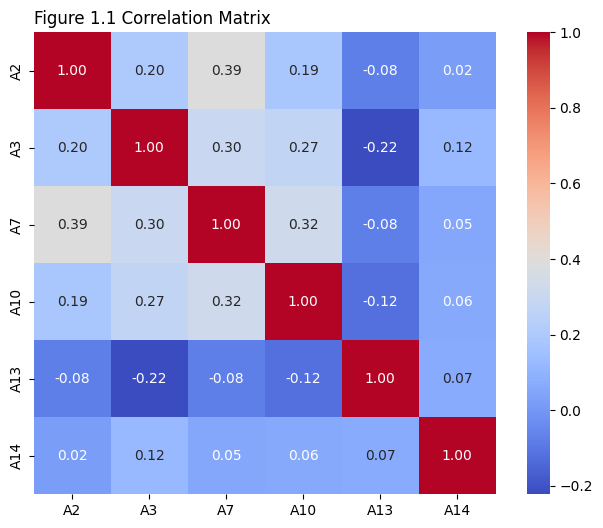

In [98]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[continuous_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Figure 1.1 Correlation Matrix', loc ='left')
plt.show()

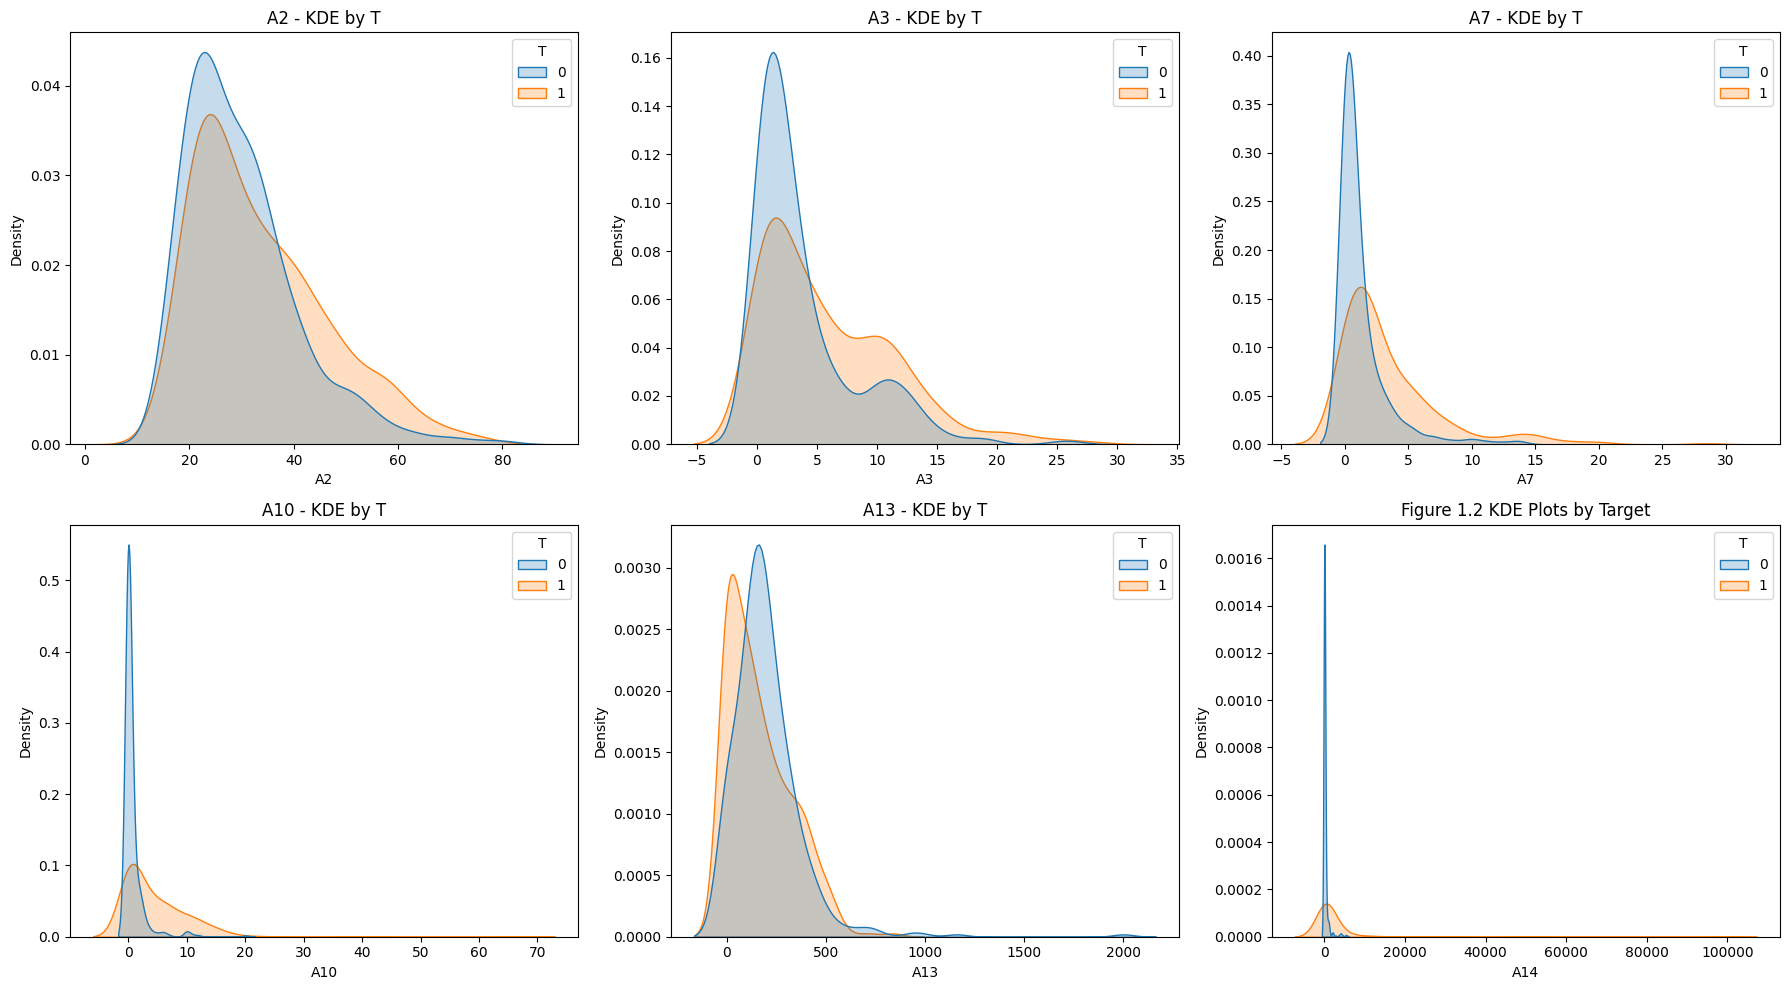

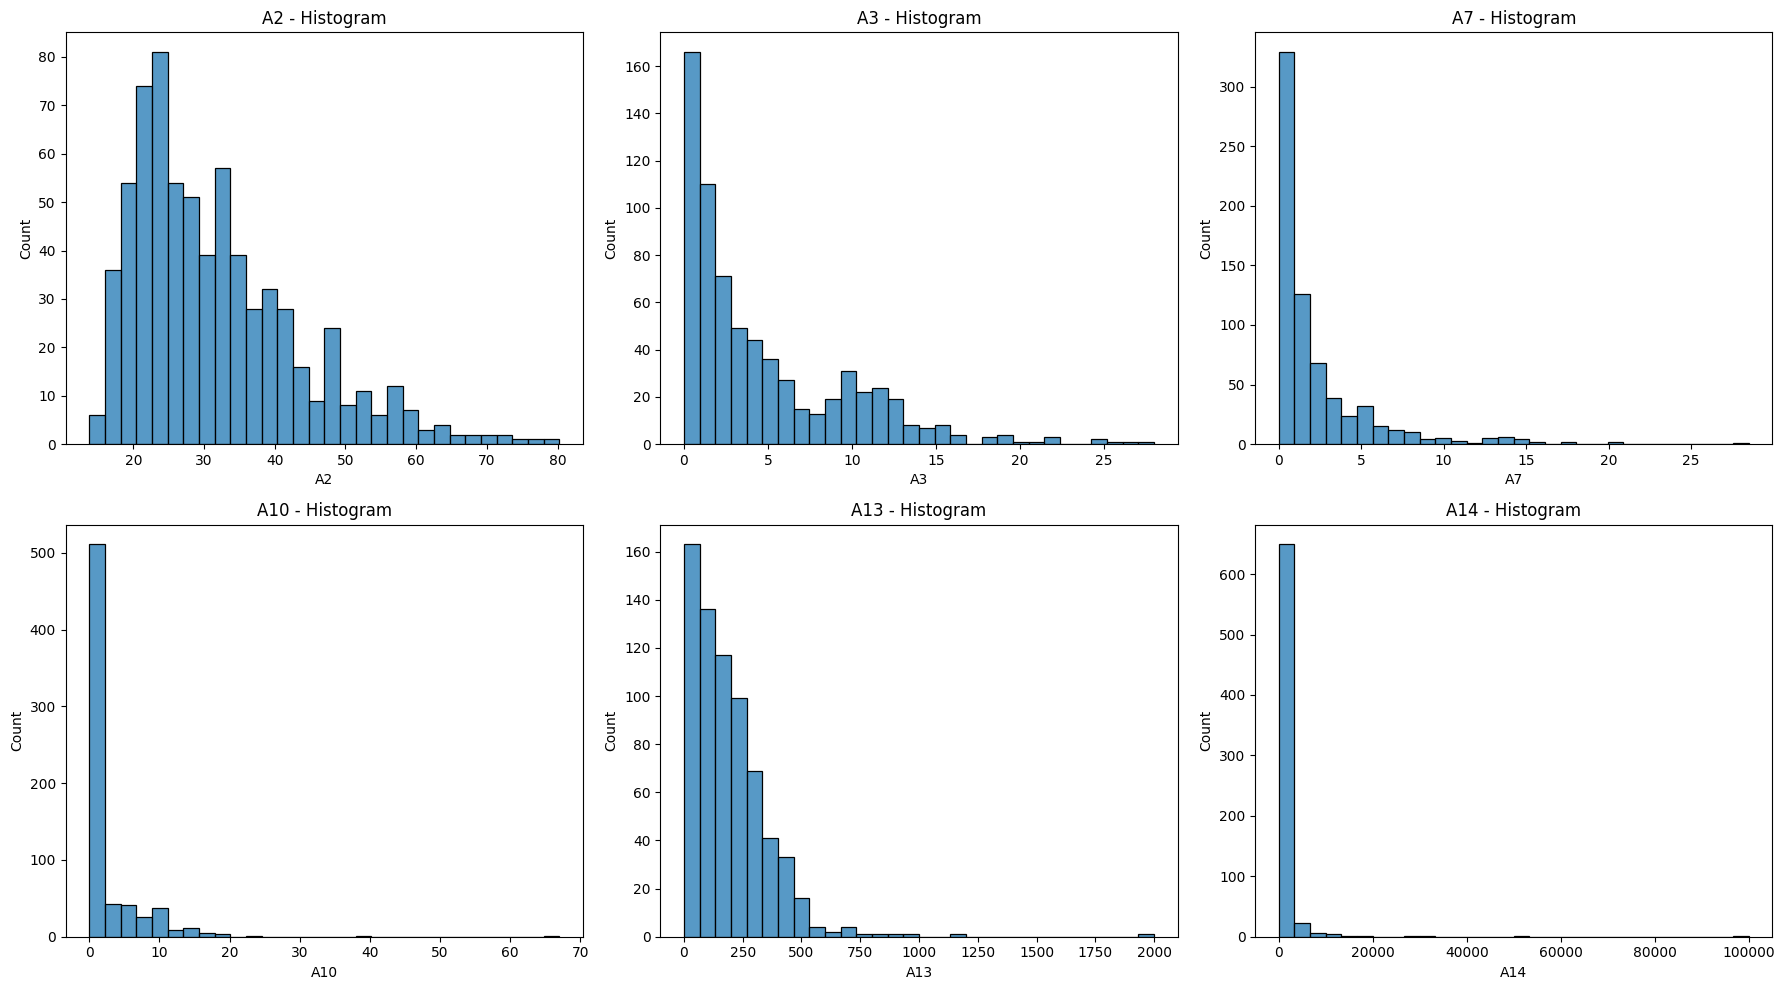

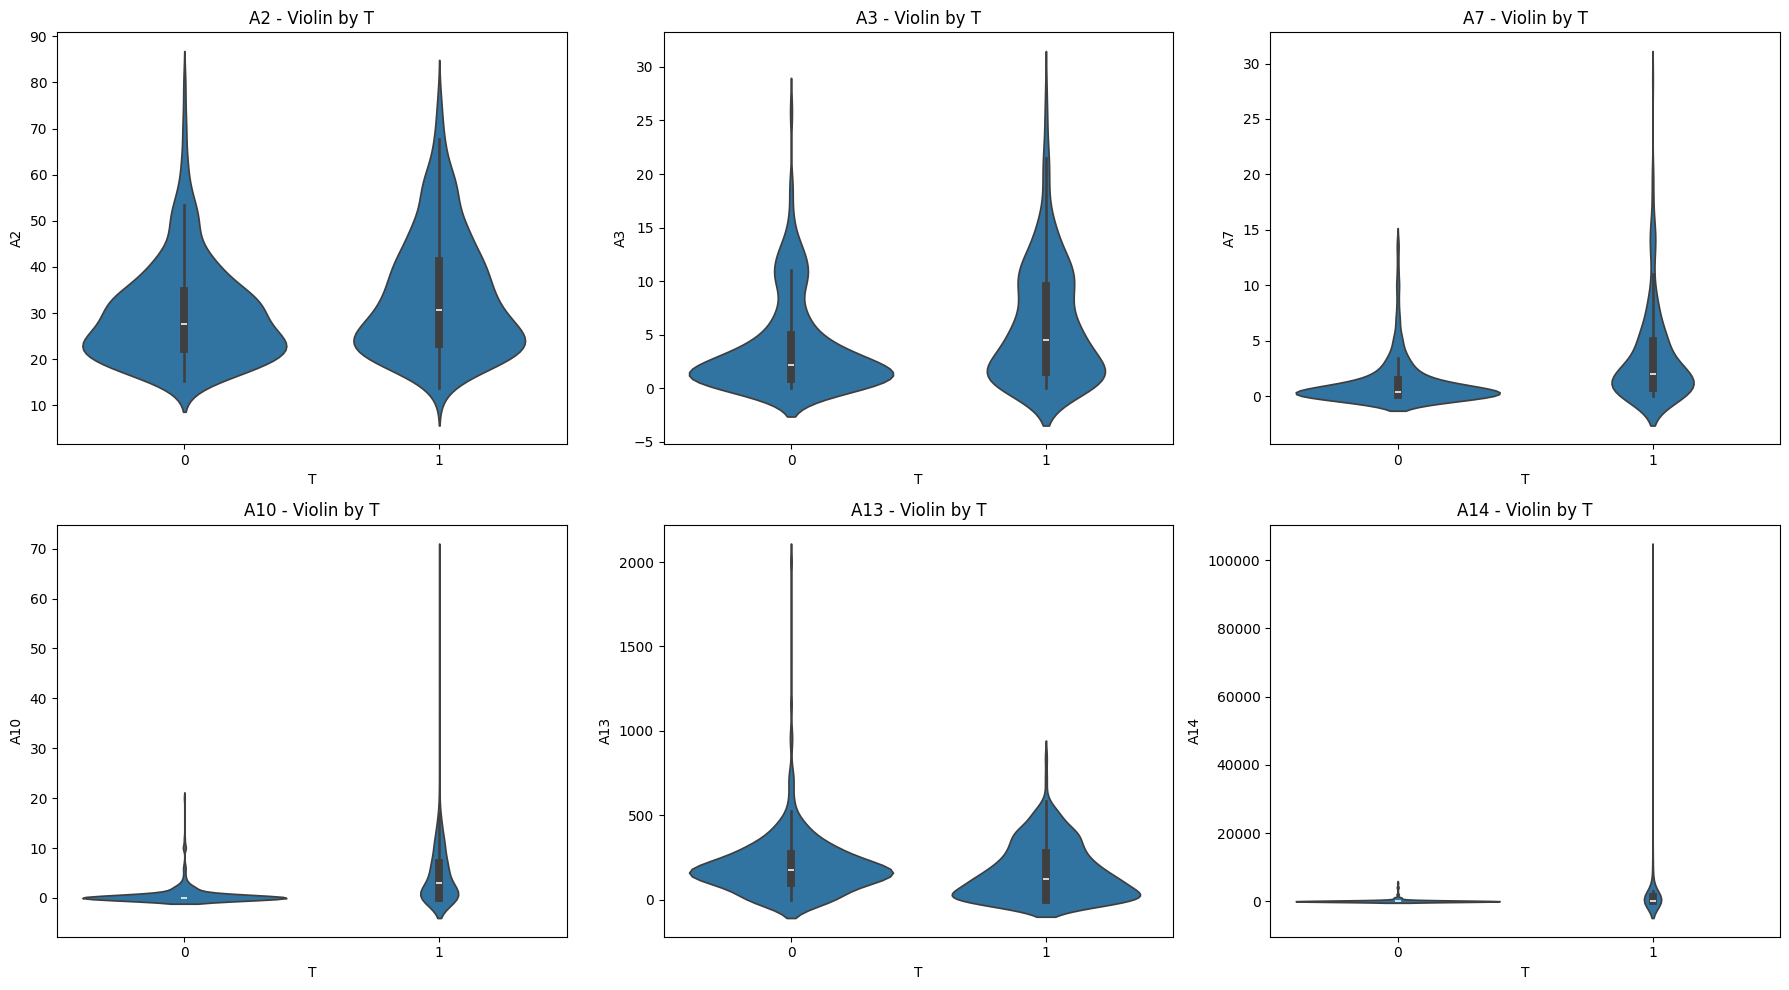

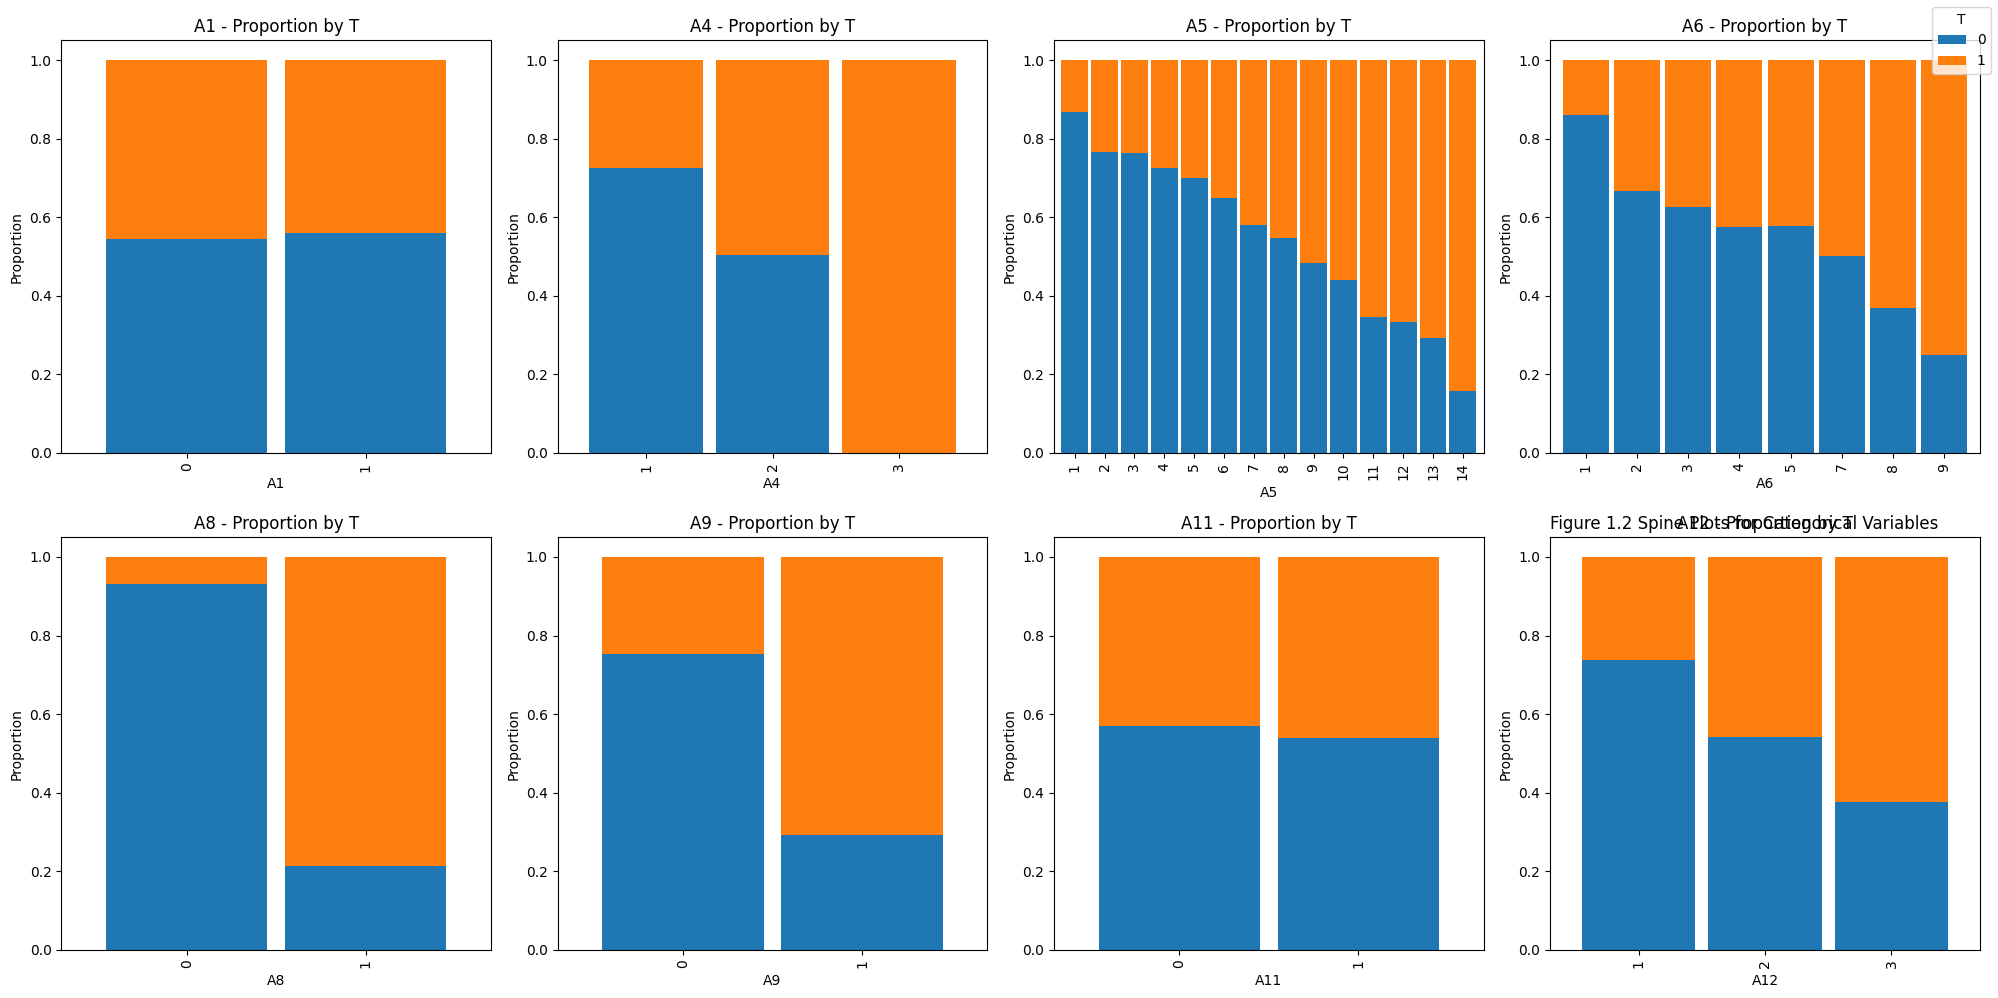

In [99]:
#gemini
#prompt: 
### Şunları çizdir:
## kde plot continuous değerler için, T target variableımızın kategorilere göre nasıl dağıldığı,
## continuous değerler için histogram T'ye kayıtsız,
## ayrıca bir de violin plot belki.
## catgeoric değerler için bir kategorinin bir level'i içinde T = 0 ve T = 1'in dağılımı, spine plot kullanabilirsin.
## pandas, sns, ve plt kullan, kod yorumlarını çok az tut 


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Verinin 'df' adlı DataFrame'de olduğunu varsayıyoruz.
categorical_columns = ["A1", "A4", "A5", "A6", "A8", "A9", "A11", "A12"]
continuous_columns = ["A2", "A3", "A7", "A10", "A13", "A14"]
target = "T"

# 1. Continuous: KDE Plot (Target'a göre)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_columns):
    sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} - KDE by {target}')

plt.title("Figure 1.2 KDE Plots by Target")
plt.tight_layout()
plt.show()

# 2. Continuous: Histogram (Target'tan bağımsız)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_columns):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} - Histogram')

plt.tight_layout()
plt.show()

# 3. Continuous: Violin Plot (Target'a göre dağılım)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_columns):
    sns.violinplot(data=df, x=target, y=col, ax=axes[i])
    axes[i].set_title(f'{col} - Violin by {target}')

plt.tight_layout()
plt.show()

# 4. Categorical: Spine Plot Alternatifi (100% Stacked Bar)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    # Her kategori seviyesi için T=0 ve T=1 oranlarını hesapla
    cross_tab = pd.crosstab(df[col], df[target], normalize='index')
    
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], legend=False, width=0.9)
    axes[i].set_title(f'{col} - Proportion by {target}')
    axes[i].set_ylabel('Proportion')
    axes[i].margins(x=0) 

# Tek bir legend ekle
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=target, loc='upper right')
plt.title("Figure 1.2 Spine Plots for Categorical Variables", loc='left')
plt.tight_layout()
plt.show()

We should benefit from some Box-Cox transformations

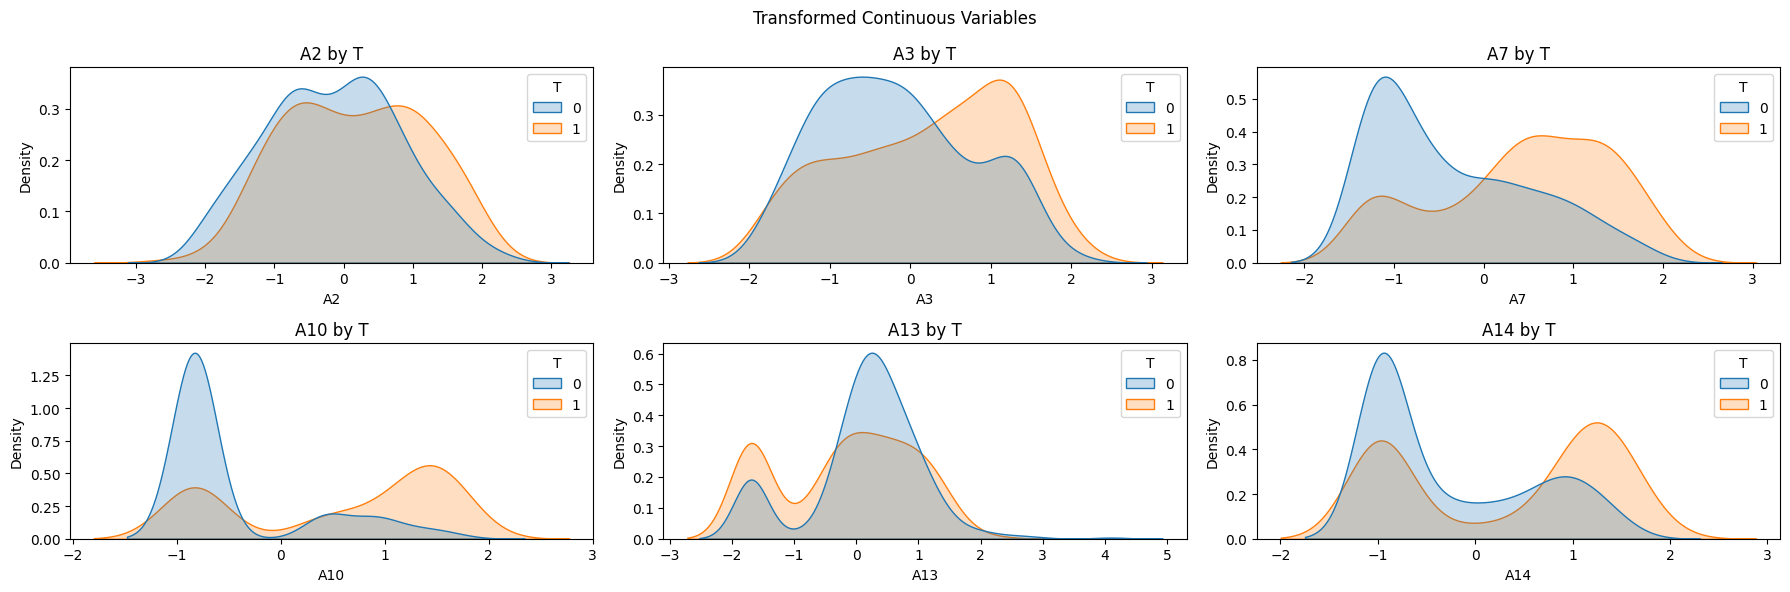

In [100]:
pt = PowerTransformer()
pt.fit(df[["A2","A3","A7","A10","A13","A14"]]) # all numeric features are skewed,
#before training models, lets see how this transformation will work out
candidates= pd.DataFrame(pt.transform(df[["A2","A3","A7","A10","A13","A14"]]), columns=["A2","A3","A7","A10","A13","A14"])
candidates["T"] = df["T"]
fig, axes = plt.subplots(2, 3, figsize=(18, 6))
fig.suptitle("Transformed Continuous Variables")
axes = axes.flatten()
for i, col in enumerate(continuous_columns):
    sns.kdeplot(data=candidates, x=col, hue=target, fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} by {target}')
plt.tight_layout()
plt.show()


Nicee

# Models - Baselines

## kNN

In [101]:

np.random.seed(1789)

metrics_all_list = []
def fetch_metrics_to_list(X_train, X_test, y_train, y_test, model, model_name, save_to_list = "yes"):
    """a function appending metrics of best performer models from searches of test and train sets"""
    train_pred, test_pred = model.predict(X_train), model.predict(X_test)
    acc_test, acc_train  = accuracy_score(y_test, test_pred), accuracy_score(y_train, train_pred)
    prec_test, prec_train = precision_score(y_test, test_pred, pos_label=1, zero_division=0), precision_score(y_train, train_pred, pos_label=1, zero_division=0)
    rec_test, rec_train  = recall_score(y_test, test_pred, pos_label=1, zero_division=0), recall_score(y_train, train_pred, pos_label=1, zero_division=0)
    f1_test, f1_train   = f1_score(y_test, test_pred, pos_label=1, zero_division=0), f1_score(y_train, train_pred, pos_label=1, zero_division=0)
    
    if hasattr(model, "predict_proba"):
        train_pred_proba = model.predict_proba(X_train)[:, 1]
        test_pred_proba  = model.predict_proba(X_test)[:, 1]
        logloss_test  = log_loss(y_test, test_pred_proba)
        logloss_train = log_loss(y_train, train_pred_proba)
   
    else:
        # Fallback for models that only output hard predictions
        logloss_test, logloss_train = None, None
    
    output = {"Model": model_name, 
              "Metrics": {"TestAccuracy": acc_test, "TrainAccuracy": acc_train,
              "TestPrecision": prec_test, "TrainPrecision": prec_train, 
              "TestRecall": rec_test, "TrainRecall": rec_train,
              "TestF1": f1_test, "TrainF1": f1_train, "TestLoss": logloss_test,"TrainLoss": logloss_train}
              }
    if save_to_list == "yes":
        metrics_all_list.append(output)
    return output

X, y = df[continuous_columns+categorical_columns].copy(), df["T"].copy()
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1789) #this case we have the holdout test cases

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns), #standardize = True for standardizing automatically
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)


knn_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", KNeighborsClassifier())
    )
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {"estimator__n_neighbors": list(range(1, 30)), "estimator__metric":["euclidean","manhattan"]}

knn_gs     = GridSearchCV(knn_pipeline,
                           param_grid, cv=cv5,
                           scoring="f1", n_jobs=-1, refit=True)

print("||oo|| KNN Search ||oo||")
print("="*30)

knn_gs.fit(X_train, y_train)
best_knn = knn_gs.best_estimator_
best_k = knn_gs.best_params_["estimator__n_neighbors"]

print(f"Best k : {best_k}")
print(f"Best CV F1 : {knn_gs.best_score_:.4f}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_knn, "K-Neighbors") 
#since we have model = best_knn, the GridSearch output automatically uses preprocessors and pipelines defined above. 


||oo|| KNN Search ||oo||
Best k : 7
Best CV F1 : 0.8526


{'Model': 'K-Neighbors',
 'Metrics': {'TestAccuracy': 0.8478260869565217,
  'TrainAccuracy': 0.9094202898550725,
  'TestPrecision': 0.8035714285714286,
  'TrainPrecision': 0.9173553719008265,
  'TestRecall': 0.8181818181818182,
  'TrainRecall': 0.8809523809523809,
  'TestF1': 0.8108108108108109,
  'TrainF1': 0.8987854251012146,
  'TestLoss': 1.566281736228519,
  'TrainLoss': 0.24117895406222672}}

In [102]:
ConfusionMatrixDisplay.from_estimator(best_knn, X_test, y_test, cmap="Blues")
plt.title("KNN Confusion Matrix")

Text(0.5, 1.0, 'KNN Confusion Matrix')

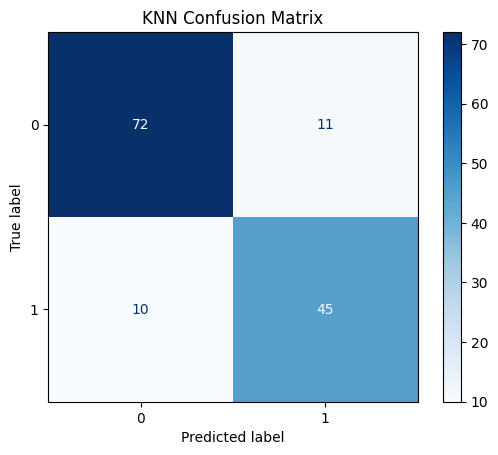

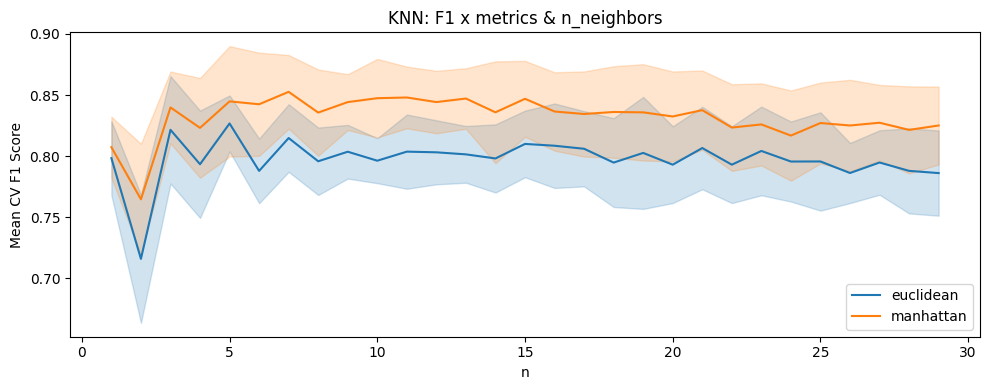

In [103]:
cv_res_knn = pd.DataFrame(knn_gs.cv_results_)
fig, ax = plt.subplots(figsize=(10, 4))
for metric in ['euclidean', 'manhattan']:
    subset = cv_res_knn[cv_res_knn['param_estimator__metric'] == metric]
    x = subset['param_estimator__n_neighbors']
    y_mean = subset['mean_test_score']
    y_std = subset['std_test_score']
    line = plt.plot(x, y_mean, label=metric)
    
    # Fill the area around the line (alpha controls the transparency of the band)
    plt.fill_between(x, 
                     y_mean - y_std, 
                     y_mean + y_std, 
                     alpha=0.2, 
                     color=line[0].get_color()) # Match the band color to the line color

plt.xlabel('n')
plt.ylabel('Mean CV F1 Score')
plt.title('KNN: F1 x metrics & n_neighbors')
plt.legend()
plt.tight_layout()
plt.show()

## Naive Bayes

Before naive bayes check for independence of features. From correlation matrix we had earlier we can see that most features have a low correlation between them, and some have medium but none higher than 0.4. 

In [104]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1789) #this case we have the holdout test cases

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns), #standardize = True for standardizing automatically
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)


knn_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", GaussianNB())
    )
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=1789)

param_grid = {
    'estimator__var_smoothing': np.logspace(0, -9, num=100) 
}

nb_gs = GridSearchCV(knn_pipeline,
                           param_grid, cv=cv5,
                           scoring="f1", n_jobs=-1, refit=True)

print("||oo|| NB Search ||oo||")
print("="*30)

nb_gs.fit(X_train, y_train)
best_nb = nb_gs.best_estimator_
y_pred = best_nb.predict(X_test)

print(f"Best Score NB: {nb_gs.best_score_:.4f}")
print(f"Best Params NB:\n{nb_gs.best_params_}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_nb, "Naive Bayes")
cv_res_nb = pd.DataFrame(nb_gs.cv_results_)



||oo|| NB Search ||oo||
Best Score NB: 0.8568
Best Params NB:
{'estimator__var_smoothing': np.float64(0.0533669923120631)}


C:\Users\elito\AppData\Local\Temp\ipykernel_6004\1859910901.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


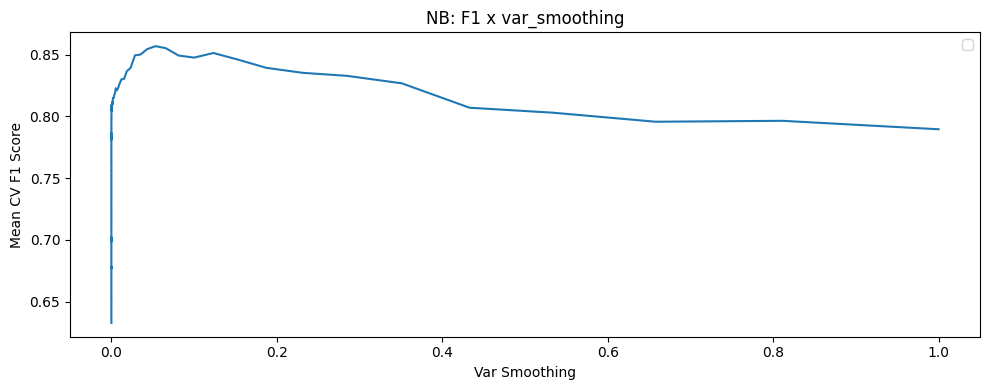

In [105]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(y = cv_res_nb["mean_test_score"], x = cv_res_nb["param_estimator__var_smoothing"])
plt.xlabel('Var Smoothing')
plt.ylabel('Mean CV F1 Score')
plt.title('NB: F1 x var_smoothing')
plt.legend()
plt.tight_layout()
plt.show()

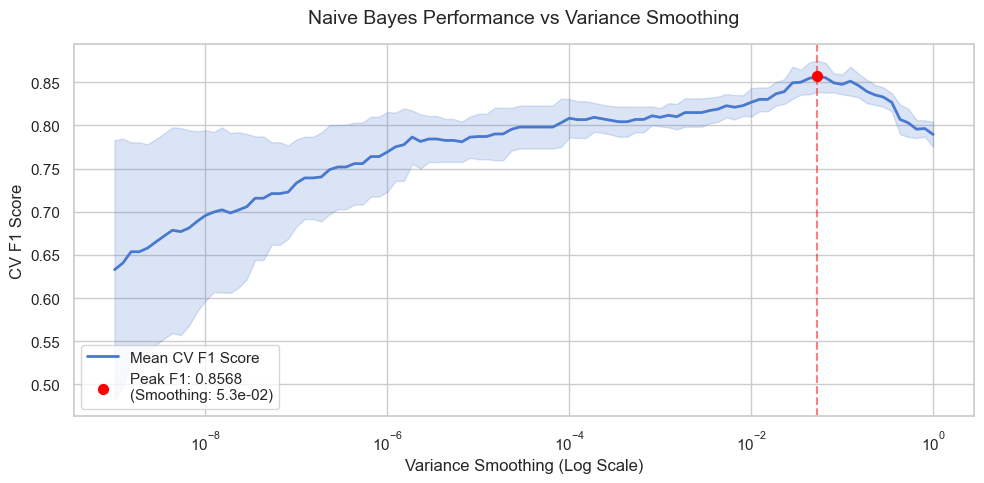

In [106]:
#generated by gemini with following prompt: 
#make this look prettier, with attached image as output of the last code block. 
# Set a cleaner style
sns.set_theme(style="whitegrid", palette="muted")

# 1. Setup the figure
plt.figure(figsize=(10, 5))

# 2. Extract the arrays (ensuring x is numeric for plotting)
x = np.array(cv_res_nb["param_estimator__var_smoothing"].tolist(), dtype=float)
y_mean = cv_res_nb["mean_test_score"]
y_std = cv_res_nb["std_test_score"]

# 3. Plot the main line and the error bands
line = plt.plot(x, y_mean, label='Mean CV F1 Score', linewidth=2)
plt.fill_between(x, 
                 y_mean - y_std, 
                 y_mean + y_std, 
                 alpha=0.2, 
                 color=line[0].get_color())

# 4. Find and highlight the absolute maximum F1 Score
max_idx = np.argmax(y_mean)
best_x = x[max_idx]
best_y = y_mean[max_idx]

plt.scatter(best_x, best_y, color='red', s=50, zorder=5, 
            label=f'Peak F1: {best_y:.4f}\n(Smoothing: {best_x:.1e})')
plt.axvline(best_x, color='red', linestyle='--', alpha=0.5)

# 5. The Magic Trick: Logarithmic X-Axis
plt.xscale('log')

# 6. Formatting
plt.title('Naive Bayes Performance vs Variance Smoothing', fontsize=14, pad=15)
plt.xlabel('Variance Smoothing (Log Scale)', fontsize=12)
plt.ylabel('CV F1 Score', fontsize=12)
plt.legend(loc='lower left') 
plt.tight_layout()
plt.show()

# Reset seaborn theme if you don't want it affecting subsequent plots
sns.reset_orig()

## SVMs

### E: Deciding on Kernel Functions


Deciding the kernel functions: 
- Which features are more important -> Run kind of MI detector, see the sklearn
- - See pairwise relationships between them, how do they seperate? 
- - Hypothesize Two relationships
- - In gridsearch, look for all kernels


In [107]:
from sklearn.feature_selection import mutual_info_classif
df_mi = df.copy()
pt = PowerTransformer()
df_mi[["A2","A3","A7","A10","A13","A14"]] = pt.fit_transform(df_mi[["A2","A3","A7","A10","A13","A14"]]) # all numeric features are skewed,

X_mi = preprocessor.fit_transform(X)
y_mi = y.copy()
features = preprocessor.get_feature_names_out()
is_discrete = [name.startswith('cat') for name in features]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=is_discrete, random_state=42)
mi_series = pd.Series(mi_scores, index=preprocessor.get_feature_names_out()).sort_values(ascending=False)

print("--- Feature Information Rankings ---")
mi_series.head(n=10)

#

--- Feature Information Rankings ---


cat__A8_0     0.295079
cat__A8_1     0.295079
num__A10      0.184605
num__A14      0.117418
cat__A9_0     0.108329
cat__A9_1     0.108329
num__A7       0.074996
num__A13      0.037727
num__A2       0.019817
cat__A5_14    0.019685
dtype: float64

Most informative features are A8, A10 and A14

In [108]:
df["A10"].value_counts()

A10
0.0     395
1.0      71
2.0      45
3.0      28
6.0      23
11.0     19
5.0      18
7.0      16
4.0      15
9.0      10
8.0      10
14.0      8
12.0      8
10.0      8
15.0      4
16.0      3
17.0      2
20.0      2
67.0      1
19.0      1
40.0      1
13.0      1
23.0      1
Name: count, dtype: int64

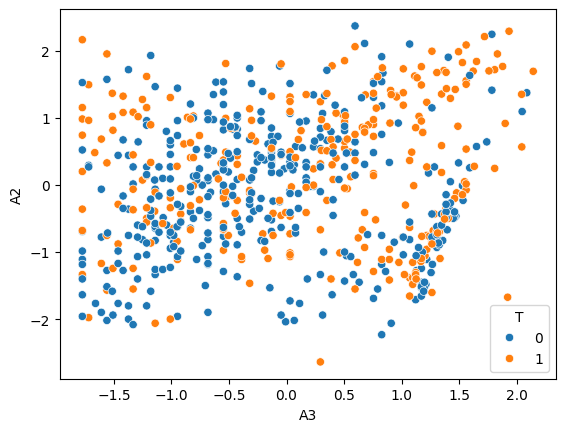

In [109]:
sns.scatterplot(x=df_mi["A3"], y=df_mi["A2"], hue = df_mi["T"])
plt.show()

Note: This detection bussiness is postponed. Probably nothing good will come out anyways. I am just going to run my search algorithm.

### Continuing SVMs

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1789) #this case we have the holdout test cases

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns), #standardize = True for standardizing automatically
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

svm_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", SVC(random_state=1789))
    )
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=1789)

param_grid = [
    {
        'estimator__kernel': ['linear'],
        'estimator__C': [0.1, 1, 10, 100]
    },
    {
        'estimator__kernel': ['rbf'],
        'estimator__C': [0.1, 1, 10, 100],
        'estimator__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10]
    },
    {
        'estimator__kernel': ['poly'],
        'estimator__C': [0.1, 1, 10],
        'estimator__degree': [2, 3],
        'estimator__gamma': ['scale', 0.1, 1],
        'estimator__coef0': [0, 1, 5]
    },
    {
        'estimator__kernel': ['poly'],
        'estimator__C': [0.1, 1, 10],
        'estimator__gamma': ['scale', 0.1],
        'estimator__coef0': [0, 1, 5]
    }
] 
svm_gs = GridSearchCV(svm_pipeline,
                    param_grid, cv=cv5,
                    scoring="f1", n_jobs=-1,
                    refit=True)

print("||oo|| SVM Search ||oo||")
print("="*30)

svm_gs.fit(X_train, y_train)
best_svm = svm_gs.best_estimator_
y_pred = best_svm.predict(X_test)

print(f"Best Score SVM: {svm_gs.best_score_:.4f}")
print(f"Best Params SVM:\n{svm_gs.best_params_}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_svm, "SVM")
cv_res_svm = svm_gs.cv_results_

||oo|| SVM Search ||oo||
Best Score SVM: 0.8732
Best Params SVM:
{'estimator__C': 100, 'estimator__gamma': 0.01, 'estimator__kernel': 'rbf'}


# Ensemble Methods
- Write the code for tuning and fitting, 
- Extract data

## RandomForest

In [111]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1789) #this case we have the holdout test cases

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", continuous_columns), #standardize = True for standardizing automatically
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

rf_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", RandomForestClassifier(random_state=1789, oob_score=True))
    )
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=1789)

param_dist = {
    "estimator__n_estimators": randint(40, 400), 
    "estimator__max_depth": [5, 10, 15, 20, 25], 
    "estimator__min_samples_split": randint(2, 25), 
    "estimator__min_samples_leaf": randint(1, 15),
    "estimator__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "estimator__max_samples": [0.6, 0.7, 0.8, 0.9]
}

rf_randomsearch = RandomizedSearchCV(estimator=rf_pipeline,
                                     cv=cv5,
                                     param_distributions=param_dist,
                                     n_jobs=-1, n_iter=500
                                     )
rf_randomsearch.fit(X_train, y_train)

rf_random_best = rf_randomsearch.best_estimator_
cv_res_rsearch_rforest = rf_randomsearch.cv_results_

print("Random Search for Random Forest")
print(f"Best Parameters:{rf_randomsearch.best_params_}")

bp = rf_randomsearch.best_params_
param_grid = {
    "estimator__n_estimators": [max(40, bp["estimator__n_estimators"]-50), 
                                bp["estimator__n_estimators"], 
                                bp["estimator__n_estimators"]+40],
    "estimator__max_depth": [max(bp["estimator__max_depth"]-5, 3), 
                             bp["estimator__max_depth"], 
                             bp["estimator__max_depth"]+5], 
    "estimator__min_samples_split": [max(bp["estimator__min_samples_split"]-5, 1),
                                     bp["estimator__min_samples_split"],
                                     bp["estimator__min_samples_split"]+5], 
    "estimator__min_samples_leaf": [max(bp["estimator__min_samples_leaf"]-3, 1),
                                    bp["estimator__min_samples_leaf"],
                                    bp["estimator__min_samples_leaf"]+3],
    "estimator__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "estimator__max_samples": [max(bp["estimator__max_samples"]-0.1, 0.1),
                               bp["estimator__max_samples"],
                               bp["estimator__max_samples"]+0.1]
}

rf_gs = GridSearchCV(rf_pipeline,
                    param_grid, cv=cv5,
                    scoring="f1", n_jobs=-1,
                    refit=True)

print("||oo|| Random Forest Search ||oo||")
print("="*30)

rf_gs.fit(X_train, y_train)
best_rf = rf_gs.best_estimator_
y_pred = best_rf.predict(X_test)
best_params_rf = rf_gs.best_params_
print(f"Best Score Random Forest: {rf_gs.best_score_:.4f}")
print(f"Best Params Random Forest:\n{best_params_rf}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_rf, "RandomForest")
cv_res_rf = rf_gs.cv_results_


Random Search for Random Forest
Best Parameters:{'estimator__max_depth': 25, 'estimator__max_features': 'log2', 'estimator__max_samples': 0.9, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 3, 'estimator__n_estimators': 176}
||oo|| Random Forest Search ||oo||


c:\Users\elito\miniconda3\envs\noobData\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2025 fits failed out of a total of 6075.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2025 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\elito\miniconda3\envs\noobData\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\elito\miniconda3\envs\noobData\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\elito\miniconda3\envs\noobData\Lib\site-packages\im

Best Score Random Forest: 0.8804
Best Params Random Forest:
{'estimator__max_depth': 20, 'estimator__max_features': 'log2', 'estimator__max_samples': 0.8, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 3, 'estimator__n_estimators': 126}


### Feature Importance


In [152]:
best_rf_model = best_rf["estimator"]
fi = best_rf_model.feature_importances_
feature_names = best_rf['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame(fi, feature_names, columns=["Importance"])

In [155]:
feature_importance_df.sort_values(by="Importance", ascending=False)

,Importance
cat__A8_1,0.174623
cat__A8_0,0.151293
num__A14,0.079592
num__A7,0.075030
num__A3,0.065783
num__A10,0.058437
num__A2,0.056269
num__A13,0.051970
cat__A9_0,0.046759
cat__A9_1,0.043277


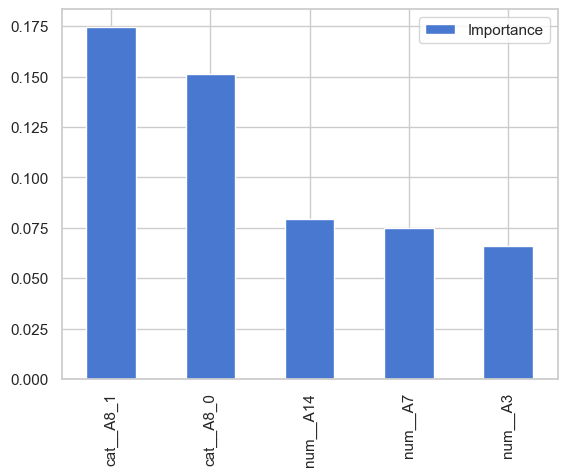

In [168]:
feature_importance_df.sort_values(by="Importance", ascending=False).head(5).plot(kind="bar")
plt.show()

## XGBoost

In [112]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", continuous_columns), #standardize = True for standardizing automatically
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

xgb_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", XGBClassifier(eval_metric="logloss", use_label_encoder=False, random_state=1789, n_jobs=-1))
    )
)
#here I might just  use xgboost by itself, but for consistency of the code I pass it through the pipeline
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=1789)

param_dist = {
    "estimator__n_estimators": randint(50, 600),
    "estimator__learning_rate": loguniform(1e-3, 0.4),
    "estimator__max_depth": randint(2, 10),
    "estimator__min_child_weight": randint(1, 20),
    "estimator__gamma": uniform(0.0, 5.0),
    "estimator__subsample": uniform(0.4, 0.6),
    "estimator__colsample_bytree": uniform(0.4, 0.6),
    "estimator__colsample_bylevel": uniform(0.4, 0.6),
    "estimator__reg_alpha": loguniform(1e-8, 10.0),
    "estimator__reg_lambda": loguniform(1e-8, 10.0),
    "estimator__scale_pos_weight": uniform(0.5, 2.5) 
}

xgb_randomsearch = RandomizedSearchCV(estimator=xgb_pipeline,
                                      cv=cv3,
                                      param_distributions=param_dist, 
                                      scoring="f1", n_jobs=-1, n_iter=500)
xgb_randomsearch.fit(X_train, y_train)

print("Random Search for XGBoost")
best_params_xgb = xgb_randomsearch.best_params_
print(f"Best Parameters:{best_params_xgb}")

best_xgb = xgb_randomsearch.best_estimator_

print(f"Best Score XGBoost: {xgb_randomsearch.best_score_:.4f}")
print(f"Best Params XGBoost:\n{xgb_randomsearch.best_params_}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_xgb, "XGBoost")

Random Search for XGBoost
Best Parameters:{'estimator__colsample_bylevel': np.float64(0.6884480215892128), 'estimator__colsample_bytree': np.float64(0.7671259985760056), 'estimator__gamma': np.float64(3.434442761906676), 'estimator__learning_rate': np.float64(0.23494110675072433), 'estimator__max_depth': 4, 'estimator__min_child_weight': 5, 'estimator__n_estimators': 375, 'estimator__reg_alpha': np.float64(1.8594963191027661e-07), 'estimator__reg_lambda': np.float64(1.9573684546649516e-05), 'estimator__scale_pos_weight': np.float64(2.058629477287134), 'estimator__subsample': np.float64(0.7006129898310385)}
Best Score XGBoost: 0.8735
Best Params XGBoost:
{'estimator__colsample_bylevel': np.float64(0.6884480215892128), 'estimator__colsample_bytree': np.float64(0.7671259985760056), 'estimator__gamma': np.float64(3.434442761906676), 'estimator__learning_rate': np.float64(0.23494110675072433), 'estimator__max_depth': 4, 'estimator__min_child_weight': 5, 'estimator__n_estimators': 375, 'esti

c:\Users\elito\miniconda3\envs\noobData\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:11:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'Model': 'XGBoost',
 'Metrics': {'TestAccuracy': 0.8695652173913043,
  'TrainAccuracy': 0.9311594202898551,
  'TestPrecision': 0.7936507936507936,
  'TrainPrecision': 0.8933823529411765,
  'TestRecall': 0.9090909090909091,
  'TrainRecall': 0.9642857142857143,
  'TestF1': 0.847457627118644,
  'TrainF1': 0.9274809160305344,
  'TestLoss': 0.3578673412073854,
  'TrainLoss': 0.19028702713064335}}

## Comparison of Bias & Variance Profiles

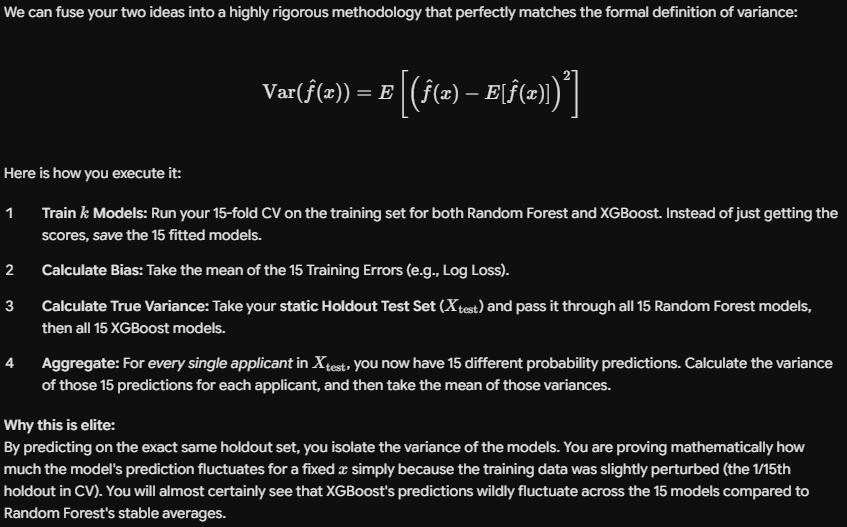

In [113]:
[np.random.randint(1, 1.e6, 3) for seed in range(3)]

[array([ 35327, 850114, 679623], dtype=int32),
 array([758019, 274536, 126275], dtype=int32),
 array([464577, 182716, 154059], dtype=int32)]

In [ ]:
# the bias profile: of 15 cross validatied models, pick training loss as sample for both rf and xgb
# the variance profile: run 15 cross validated models on test set as sample for rf and xgb variance

best_params_xgb = xgb_randomsearch.best_params_
best_params_rf = rf_gs.best_params_
best_params_xgb_cleaned = {k.replace("estimator__", ""): v for k, v in best_params_xgb.items()}
best_params_rf_cleaned = {k.replace("estimator__", ""): v for k, v in best_params_rf.items()}

X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.2, random_state=1878)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns), #standardize = True for standardizing automatically
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

rng = np.random.default_rng(1789)
n = 30
seeds = [rng.integers(1, 1.e6, 5) for _ in range(n)] #generate 3x15 seeds
# models: best_rf, best_xg
for i in range(n): 
    rs1, rs2, rs3, rs4, rs5 = seeds[i] #generate random states in each iteration of the function, 
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = train_test_split(X_train, y_train, test_size=0.2, random_state=rs1)
    
    preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns), #standardize = True for standardizing automatically
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
    )
    
    xgb_optimized = XGBClassifier(**best_params_xgb_cleaned, random_state=rs2)
    rf_optimized = RandomForestClassifier(**best_params_rf_cleaned, random_state=rs3)
    xgb_base = XGBClassifier(random_state=rs4)
    rf_base = RandomForestClassifier(random_state=rs5)

    X_train_fold = preprocessor.fit_transform(X_train_fold)
    X_test_fold = preprocessor.transform(X_test_fold)
    
    xgb_optimized.fit(X_train_fold, y_train_fold)
    rf_optimized.fit(X_train_fold, y_train_fold)
    xgb_base.fit(X_train_fold, y_train_fold)
    rf_base.fit(X_train_fold, y_train_fold)

    names_models = {"Tuned_XGB": xgb_optimized, "Baseline_XGB": xgb_base,
                    "Tuned_RF": rf_optimized, "Baseline_RF": rf_base}

    for j, (model_name, model) in enumerate(names_models.items()): 
        fetch_metrics_to_list(X_test_fold, X_holdout, y_test_fold, y_holdout, model, model_name=f"__{model_name}_{i+1}") #<NOTE> the train values stand for cross validation of model
    print(f"Iteration: {i+1} done.")



    

Iteration: 1 done.
Iteration: 2 done.
Iteration: 3 done.
Iteration: 4 done.
Iteration: 5 done.
Iteration: 6 done.
Iteration: 7 done.
Iteration: 8 done.
Iteration: 9 done.
Iteration: 10 done.
Iteration: 11 done.
Iteration: 12 done.
Iteration: 13 done.
Iteration: 14 done.
Iteration: 15 done.
Iteration: 16 done.
Iteration: 17 done.
Iteration: 18 done.
Iteration: 19 done.
Iteration: 20 done.
Iteration: 21 done.
Iteration: 22 done.
Iteration: 23 done.
Iteration: 24 done.
Iteration: 25 done.
Iteration: 26 done.
Iteration: 27 done.
Iteration: 28 done.
Iteration: 29 done.
Iteration: 30 done.


In [115]:
ep_dict = [{'Model': item['Model'], **item['Metrics']} for item in metrics_all_list]
ep = pd.DataFrame(ep_dict)

In [116]:
ep.head(10)

,Model,TestAccuracy,TrainAccuracy,TestPrecision,TrainPrecision,TestRecall,TrainRecall,TestF1,TrainF1,TestLoss,TrainLoss
0,K-Neighbors,0.847826,0.909420,0.803571,0.917355,0.818182,0.880952,0.810811,0.898785,1.566282,0.241179
1,Naive Bayes,0.862319,0.869565,0.810345,0.865854,0.854545,0.845238,0.831858,0.855422,0.890130,0.697547
2,SVM,0.818841,0.936594,0.767857,0.925490,0.781818,0.936508,0.774775,0.930966,NaN,NaN
3,RandomForest,0.862319,0.980072,0.833333,0.987854,0.818182,0.968254,0.825688,0.977956,0.329588,0.133241
4,XGBoost,0.869565,0.931159,0.793651,0.893382,0.909091,0.964286,0.847458,0.927481,0.357867,0.190287
5,__Tuned_XGB_1,0.837838,0.920635,0.773585,0.879070,0.872340,0.954545,0.820000,0.915254,0.378568,0.185396
6,__Baseline_XGB_1,0.882883,1.000000,0.854167,1.000000,0.872340,1.000000,0.863158,1.000000,0.431911,0.019496
7,__Tuned_RF_1,0.855856,0.972789,0.816327,0.979381,0.851064,0.959596,0.833333,0.969388,0.335378,0.132429
8,__Baseline_RF_1,0.846847,1.000000,0.812500,1.000000,0.829787,1.000000,0.821053,1.000000,0.630209,0.083810
9,__Tuned_XGB_2,0.819820,0.918367,0.764706,0.871560,0.829787,0.959596,0.795918,0.913462,0.458488,0.184342


In [117]:
ep_dict = [{'Model': item['Model'], **item['Metrics']} for item in metrics_all_list]
ep = pd.DataFrame(ep_dict)
ep = ep.iloc[5:,:]
ep['Tuning'] = np.where(ep['Model'].str.contains('Tuned'), 'Tuned', 'Base')
ep['Bag/Boost'] = np.where(ep['Model'].str.contains('XGB'), 'Boosting', 'Bagging')
ep.head()

,Model,TestAccuracy,TrainAccuracy,TestPrecision,TrainPrecision,TestRecall,TrainRecall,TestF1,TrainF1,TestLoss,TrainLoss,Tuning,Bag/Boost
5,__Tuned_XGB_1,0.837838,0.920635,0.773585,0.879070,0.872340,0.954545,0.820000,0.915254,0.378568,0.185396,Tuned,Boosting
6,__Baseline_XGB_1,0.882883,1.000000,0.854167,1.000000,0.872340,1.000000,0.863158,1.000000,0.431911,0.019496,Base,Boosting
7,__Tuned_RF_1,0.855856,0.972789,0.816327,0.979381,0.851064,0.959596,0.833333,0.969388,0.335378,0.132429,Tuned,Bagging
8,__Baseline_RF_1,0.846847,1.000000,0.812500,1.000000,0.829787,1.000000,0.821053,1.000000,0.630209,0.083810,Base,Bagging
9,__Tuned_XGB_2,0.819820,0.918367,0.764706,0.871560,0.829787,0.959596,0.795918,0.913462,0.458488,0.184342,Tuned,Boosting


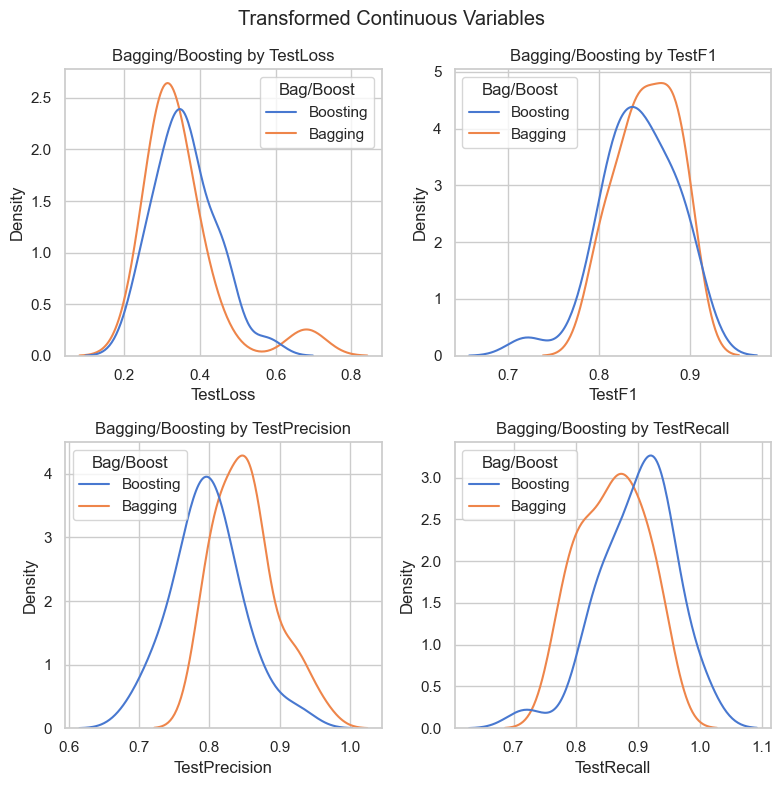

In [129]:
target_metrics = ["TestLoss", "TestF1","TestPrecision","TestRecall"] 
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Transformed Continuous Variables")
axes = axes.flatten()
for i, col in enumerate(target_metrics):
    sns.kdeplot(data=ep[ep["Tuning"]=="Tuned"], x=col, hue="Bag/Boost", ax=axes[i])
    axes[i].set_title(f'Bagging/Boosting by {col}')
plt.tight_layout()
plt.show()

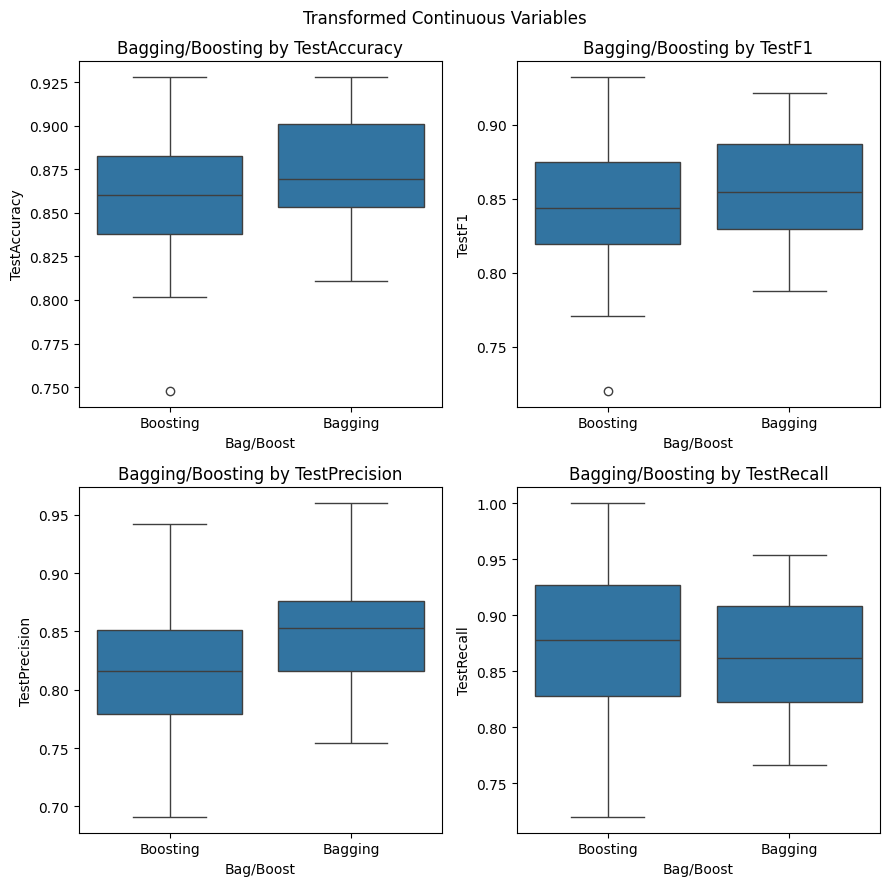

In [ ]:
target_metrics = ["TestAccuracy", "TestF1","TestPrecision","TestRecall","TestLoss"] #since classes are balanced no need to look at them seperately
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
fig.suptitle("Transformed Continuous Variables")
axes = axes.flatten()
for i, col in enumerate(target_metrics):
    sns.boxplot(data=ep, y=col, x="Bag/Boost", ax=axes[i])
    axes[i].set_title(f'Bagging/Boosting by {col}')
plt.tight_layout()
plt.show()

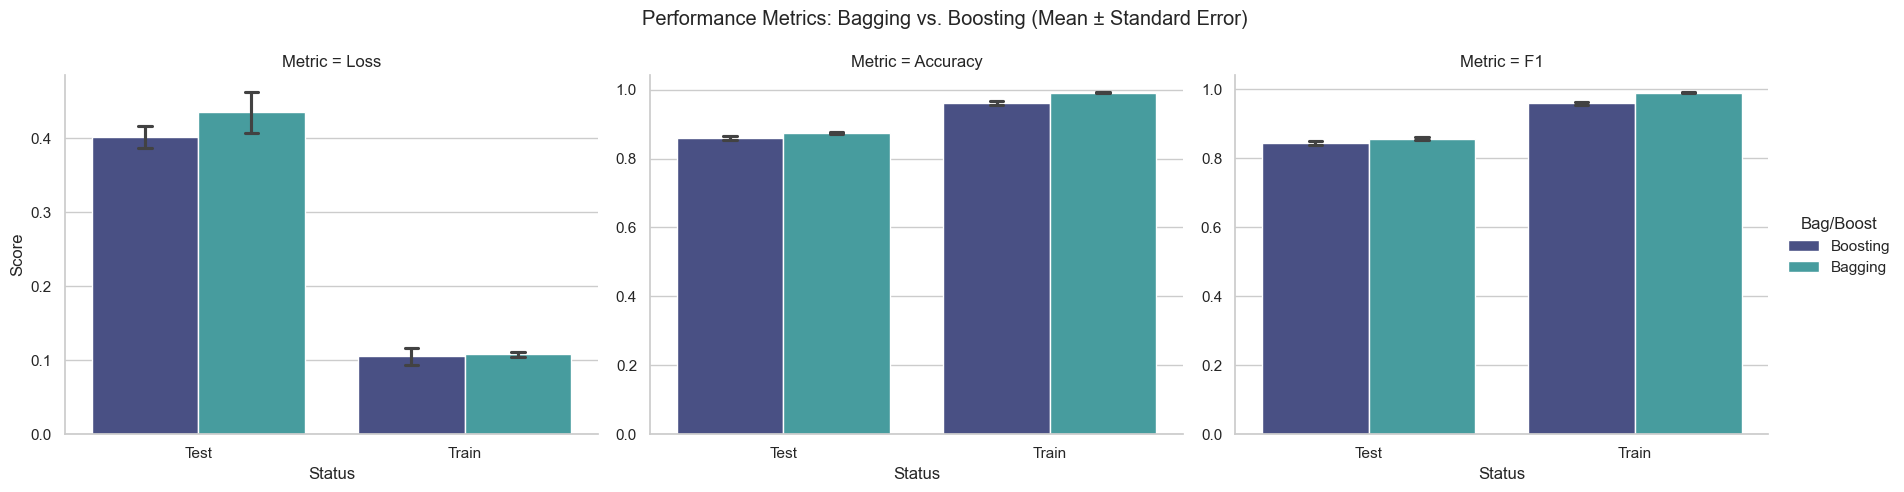

In [131]:
cols_to_keep = [
    'Bag/Boost', 
    'TestLoss', 'TrainLoss', 
    'TestAccuracy', 'TrainAccuracy', 
    'TestF1', 'TrainF1'
]
plot_df = ep[cols_to_keep].copy()

# 2. Melt the dataframe from "Wide" to "Long" format
melted_df = plot_df.melt(
    id_vars=['Bag/Boost'], 
    var_name='Original_Metric', 
    value_name='Score'
)

# 3. Extract the 'Status' (Test or Train) and the core 'Metric' (Loss, Accuracy, F1)
# If the original string contains 'Test', label it 'Test', else 'Train'
melted_df['Status'] = melted_df['Original_Metric'].apply(lambda x: 'Test' if 'Test' in x else 'Train')

# Strip out the words 'Test' and 'Train' to just leave the core metric name
melted_df['Metric'] = melted_df['Original_Metric'].str.replace('Test', '').str.replace('Train', '')

# 4. Generate the faceted barplot
# We set sharey=False because Loss operates on a different mathematical scale than Accuracy/F1
g = sns.catplot(
    data=melted_df,
    x='Status',           # Separate by Test / Train on the x-axis
    y='Score',
    hue='Bag/Boost',      # Color by main shade of Boosting vs Bagging
    col='Metric',         # Create 3 separate plots for Loss, Accuracy, F1
    kind='bar',
    errorbar='se',        # Standard Error bars
    capsize=0.1,          # Adds little caps to the top of the error bars for readability
    sharey=False,         
    height=5, 
    aspect=1.2,
    palette="mako"        # A clean, professional blue/green color palette
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Performance Metrics: Bagging vs. Boosting (Mean ± Standard Error)")

plt.show()

In [136]:
results = ep.groupby(["Bag/Boost", "Tuning"]).agg({
    "TestAccuracy":['mean','var','std'],
    "TestLoss":['mean','var','std']
})
results.head()

TestAccuracy                      TestLoss            \
                         mean       var       std      mean       var   
Bag/Boost Tuning                                                        
Bagging   Base       0.875676  0.000819  0.028626  0.520289  0.065930   
          Tuned      0.871471  0.000710  0.026655  0.349483  0.010535   
Boosting  Base       0.864264  0.001069  0.032691  0.442712  0.016368   
          Tuned      0.854955  0.001295  0.035986  0.360720  0.006382   

                            
                       std  
Bag/Boost Tuning            
Bagging   Base    0.256769  
          Tuned   0.102642  
Boosting  Base    0.127936  
          Tuned   0.079889

# Feedforward Neural Network

In [120]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.metrics import RecallAtPrecision, AUC, Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1789)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
    ]
)


X_train_processed = preprocessor.fit_transform(X_train).astype(np.float32)
X_test_processed = preprocessor.transform(X_test).astype(np.float32)

y_train = np.array(y_train).astype(np.float32)
y_test = np.array(y_test).astype(np.float32)

model = Sequential()

model.add(Dense(64, input_shape = (X_train_processed.shape[1], ), activation="tanh"))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation="tanh"))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(16, activation="tanh"))
model.add(BatchNormalization())

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam", 
    loss="binary_crossentropy", 
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Recall(name='recall'),
        Precision(name='precision'),
        RecallAtPrecision(precision=0.8, name='recall_at_80')
    ]
)

# 6. Callbacks & Execution
# This monitors validation loss and stops if it doesn't improve for 15 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=40, 
    restore_best_weights=True 
)

print("||oo|| Initiating Keras Training ||oo||")
print("="*35)

history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_test_processed, y_test),
    epochs=150,           # Set high, EarlyStopping will cut it off naturally
    batch_size=32,
    callbacks=[early_stop],
    verbose=1             # Shows the progress bar so you know it's working
)

print("\nTraining Complete. Best weights restored.")

||oo|| Initiating Keras Training ||oo||
Epoch 1/150


c:\Users\elito\miniconda3\envs\noobData\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5761 - auc: 0.6266 - loss: 0.7331 - precision: 0.5341 - recall: 0.5595 - recall_at_80: 0.0437 - val_accuracy: 0.7899 - val_auc: 0.8490 - val_loss: 0.4929 - val_precision: 0.7097 - val_recall: 0.8000 - val_recall_at_80: 0.7636
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7645 - auc: 0.8415 - loss: 0.4970 - precision: 0.7293 - recall: 0.7698 - recall_at_80: 0.6310 - val_accuracy: 0.8116 - val_auc: 0.8779 - val_loss: 0.4320 - val_precision: 0.7377 - val_recall: 0.8182 - val_recall_at_80: 0.7818
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7862 - auc: 0.8731 - loss: 0.4493 - precision: 0.7557 - recall: 0.7857 - recall_at_80: 0.7341 - val_accuracy: 0.8261 - val_auc: 0.8946 - val_loss: 0.3979 - val_precision: 0.7627 - val_recall: 0.8182 - val_recall_at_80: 0.8182
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8152 - auc: 0.9047 - loss: 0.3934 - precision: 0.7841 - recall: 0.8214 - 

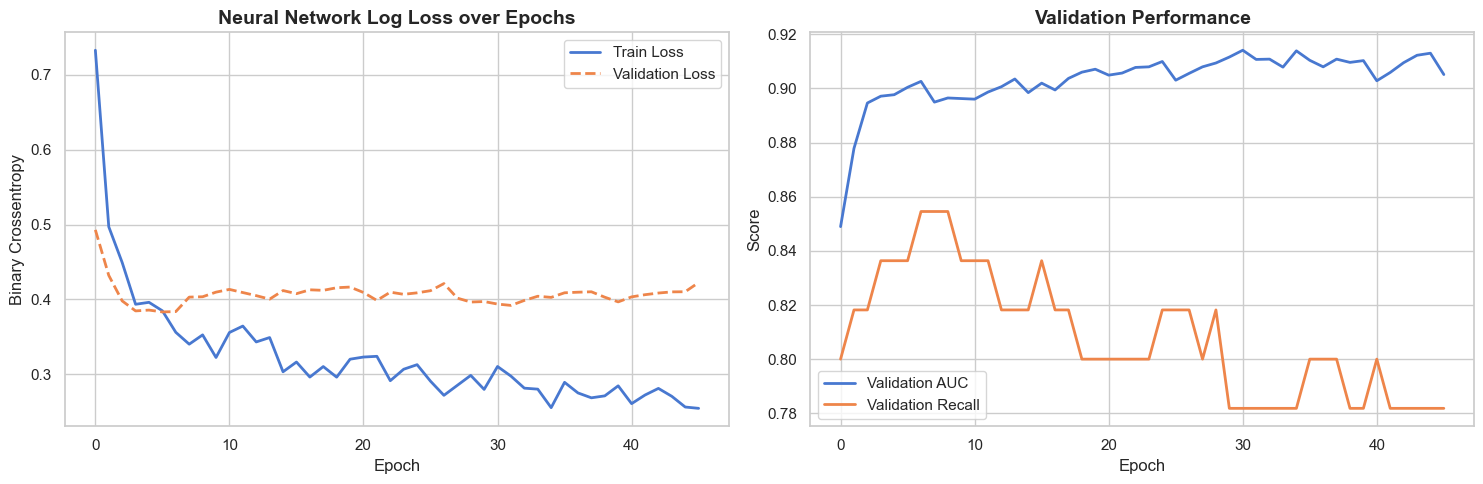

In [121]:
sns.set_theme(style="whitegrid", palette="muted")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: The Learning Curve (Loss) ---
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
ax1.set_title('Neural Network Log Loss over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Crossentropy')
ax1.legend()

# --- Plot 2: The Core Metrics ---
# Note: Keras dynamically names the metrics in the history dictionary based on how you instantiated them.
# We extract the exact keys dynamically to avoid KeyError.
val_auc_key = [k for k in history.history.keys() if 'val_auc' in k][0]
val_recall_key = [k for k in history.history.keys() if 'val_recall' in k and 'precision' not in k][0]

ax2.plot(history.history[val_auc_key], label='Validation AUC', linewidth=2)
ax2.plot(history.history[val_recall_key], label='Validation Recall', linewidth=2)
ax2.set_title('Validation Performance', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()

plt.tight_layout()
plt.show()